## FFNN (Feed Forward Neural Network) Keras

# Sharvari Shewdikar

In [29]:
# pip install tensorflow=2.10.0

In [17]:
# Import libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

In [18]:
# Sample customer feedback texts

texts = [
    "The customer service was excellent",
    "Fast delivery and good packaging",
    "I am very satisfied with the product",
    "The support team was helpful",
    "The application keeps crashing",
    "Terrible experience overall",
    "The quality is very bad",
    "Waste of money",
    "The product quality is good but the delivery was slow"
]

# Labels
# 1 = Positive
# 0 = Negative

labels = np.array([
    1, 1, 1, 1, 0, 0, 0, 0, 1
])

In [30]:
## Vectorization using TF-IDF 
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(texts).toarray()

print("Vocabulary:", vectorizer.get_feature_names_out())

print("\nNumeric Representation:")
print(X)

Vocabulary: ['application' 'bad' 'crashing' 'customer' 'delivery' 'excellent'
 'experience' 'fast' 'good' 'helpful' 'keeps' 'money' 'overall'
 'packaging' 'product' 'quality' 'satisfied' 'service' 'slow' 'support'
 'team' 'terrible' 'waste']

Numeric Representation:
[[0.         0.         0.         0.57735027 0.         0.57735027
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.57735027
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.4562658  0.
  0.         0.54020507 0.4562658  0.         0.         0.
  0.         0.54020507 0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.64525729 0.         0.76396534 0.
  0.         0.         0.         0.         0.        ]
 [0

In [31]:
## Building FFNN 
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(X.shape[1],)))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

d:\workspace\SRH\Semester_2\NLP\WA\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
## training the model 
history = model.fit(X, labels, epochs=10, batch_size=2)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4444 - loss: 0.7315  
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4444 - loss: 0.7238 
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4444 - loss: 0.7185 
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4444 - loss: 0.7132    
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4444 - loss: 0.7083 
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4444 - loss: 0.7028 
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5556 - loss: 0.6982 
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5556 - loss: 0.6937     
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5556 - loss: 0.6892 
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6667 - loss: 0.6843 


In [33]:
## testing the model
test_texts = [
    "The product is amazing and the support was great",
    "I am disappointed with the quality and delivery"
]

new_vector = vectorizer.transform(test_texts).toarray()

# make predictions
predictions = model.predict(new_vector)

print("Probability:", predictions[0][0])

if predictions[0][0] > 0.5:
    print("Predicted Label: Positive")  
else:
    print("Predicted Label: Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Probability: 0.45988378
Predicted Label: Negative


In [34]:
# pip install matplotlib

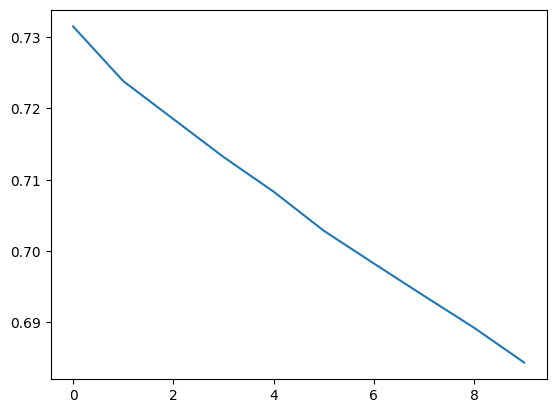

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


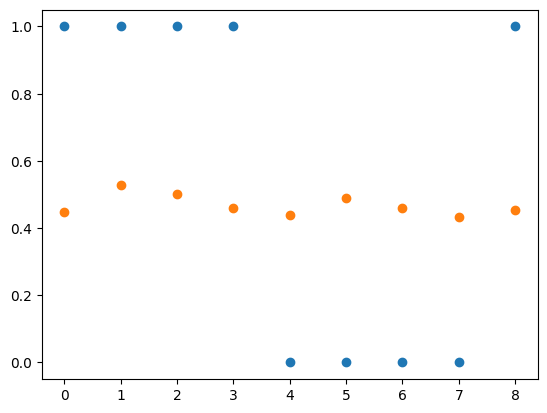

In [35]:
## visualization

import matplotlib.pyplot as plt

# training loss
plt.plot(history.history['loss'])
plt.show()

# predictions
predictions = model.predict(X).flatten()

plt.scatter(range(len(labels)), labels)
plt.scatter(range(len(predictions)), predictions)
plt.show()